# Real-vs-calculated IMF comparison

This notebook mirrors [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb) and compares clean-reference IMFs to calculated IMFs under two observation regimes. The clean-reference IMF is computed from the clean signal using the same contrast as the calculated decomposition in each grid.

**Error interpretation.** The plotted component errors are errors of the recursive IMF components, not single-pass smoothing errors at each window. In the linear case, if $W_{h_k}$ is the weighted-mean smoother and $\varepsilon = Y - X$, then

$$
e_1 = W_{h_1}\varepsilon, \qquad
e_k = W_{h_k}(I-W_{h_{k-1}})\cdots(I-W_{h_1})\varepsilon \quad (k>1).
$$

Thus the large-window noise heuristic applies to the single-pass quantities $W_{h_k}\varepsilon$. The plotted IMF errors also include the previous residual subtractions. The summary table below reports both quantities so the recursive component error can be checked against the single-pass diagnostic. The robust case is nonlinear, but the same interpretation applies because $\widetilde S^{(k)}$ is fitted to the current residual $Y^{(k)}$, not directly to the original observation $Y$.

## Setup

The signal, observation generator, window schedule, and robust gradient-descent definitions are copied from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb).

In [16]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


rng = np.random.default_rng(42)

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_MAX_WORKERS = 12

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DEFAULT_MAX_WORKERS


12

## Signal, observation, and window schedule

The contaminated observation below is exactly the `p = 0.2` setup from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb). The no-contamination observation is created later with the same seed, Gaussian scale, and contamination scale, but with `contamination_prob = 0.0`.

In [17]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)

    lower = max(1, rounded - 1)
    upper = rounded + 1
    if abs(value - lower) <= abs(upper - value):
        return lower
    return upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first

    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size

        sizes.append(candidate)
        current = candidate

    return sizes


TARGET_SIGNAL_STD = 0.38545431761087123


def gen_signal(t, seed=2026, target_std=TARGET_SIGNAL_STD):
    t = np.asarray(t, dtype=float)
    if t.ndim != 1 or len(t) < 2:
        raise ValueError("t must be a one-dimensional array with at least two points")
    if target_std <= 0:
        raise ValueError("target_std must be positive")

    rng = np.random.default_rng(seed)
    t_span = np.ptp(t)
    if t_span <= 0:
        raise ValueError("t must span a positive interval")
    u = (t - t.min()) / t_span

    def center_and_scale(values, scale):
        values = np.asarray(values, dtype=float) - np.mean(values)
        values_std = np.std(values)
        if values_std == 0:
            return values
        return scale * values / values_std

    baseline = np.zeros_like(u)
    for harmonic in range(1, 6):
        amplitude = rng.normal(scale=1.0 / harmonic)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        baseline += amplitude * np.sin(2.0 * np.pi * harmonic * u + phase)
    baseline = center_and_scale(baseline, scale=0.36)

    amplitude_envelope = 0.75 + 0.35 * np.sin(2.0 * np.pi * (1.3 * u + 0.08) + rng.uniform(0.0, 2.0 * np.pi))
    chirp_phase = 2.0 * np.pi * (2.2 * u + 5.8 * u ** 2 + 0.35 * np.sin(2.0 * np.pi * u + rng.uniform(0.0, 2.0 * np.pi)))
    chirp = center_and_scale(amplitude_envelope * np.sin(chirp_phase), scale=0.22)

    transients = np.zeros_like(u)
    for center, width, height in zip(
        rng.uniform(0.08, 0.92, size=8),
        rng.uniform(0.008, 0.04, size=8),
        rng.normal(0.0, 1.0, size=8),
    ):
        transients += height * np.exp(-0.5 * ((u - center) / width) ** 2)
    transients = center_and_scale(transients, scale=0.30)

    texture_raw = rng.normal(size=len(u))
    texture_radius = max(3, nearest_odd(0.02 * len(u)) // 2)
    texture_offsets = np.arange(-texture_radius, texture_radius + 1)
    texture_kernel = np.exp(-0.5 * (texture_offsets / max(1.0, texture_radius / 2.5)) ** 2)
    texture_kernel = texture_kernel / texture_kernel.sum()
    texture = np.convolve(texture_raw, texture_kernel, mode="same")
    texture = center_and_scale(texture, scale=0.08)

    components = {
        "baseline": baseline,
        "chirp": chirp,
        "transients": transients,
        "texture": texture,
    }
    x = sum(components.values())
    x_std = np.std(x)
    if x_std == 0:
        raise ValueError("generated signal has zero standard deviation")

    rescale = target_std / x_std
    components = {name: component * rescale for name, component in components.items()}
    x = sum(components.values())
    return x, components


def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=0.1,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))
    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    sign = rng.choice([-1, 1], size=len(x))
    contamination *= sign

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask,
    }


n = 1000
t = np.linspace(0.0, 1.0, n)
sigma = 0.4
H = 2 * sigma

window_sizes = make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31)
x_clean, true_components = gen_signal(t)
component_sum = sum(true_components.values())

assert x_clean.shape == t.shape
assert all(component.shape == t.shape for component in true_components.values())
assert np.all(np.isfinite(x_clean))
assert all(np.all(np.isfinite(component)) for component in true_components.values())
assert np.allclose(x_clean, component_sum)
assert np.isclose(x_clean.std(), TARGET_SIGNAL_STD, rtol=1e-10, atol=1e-12)
y_observed, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.6,
    rng=np.random.default_rng(777),
)

assert window_sizes[0] == 501
assert all(size % 2 == 1 for size in window_sizes)
assert all(left > right for left, right in zip(window_sizes, window_sizes[1:]))
assert min(window_sizes) >= 31

window_schedule_df = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": [size // 2 for size in window_sizes],
    "relative_width": np.array(window_sizes) / n,
})

window_schedule_df


,stage,window_size,radius,relative_width
0,1,501,250,0.501
1,2,355,177,0.355
2,3,251,125,0.251
3,4,177,88,0.177
4,5,125,62,0.125
5,6,89,44,0.089
6,7,63,31,0.063
7,8,45,22,0.045
8,9,31,15,0.031


## Kernel, robust contrast, and lookup grid

The linear IMF uses the same Epanechnikov window weights. The robust IMF uses the same smoothed absolute contrast and lookup-grid score approximation as [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb).

In [18]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(x):
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def exact_score(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def exact_exp(residual, H):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return np.exp(-0.5 * z ** 2)


def smooth_abs_rho_exact(residual, H):
    residual = np.asarray(residual, dtype=float)
    return residual * exact_score(residual, H) + SQRT_2_OVER_PI * H * exact_exp(residual, H)


def make_lookup_grid(zmax=8.0, num=4097):
    if zmax <= 0:
        raise ValueError("zmax must be positive")
    if num < 3:
        raise ValueError("num must be at least 3")

    z_grid = np.linspace(-zmax, zmax, num)
    return {
        "z": z_grid,
        "score": erf_approx(z_grid / SQRT_2),
        "exp": np.exp(-0.5 * z_grid ** 2),
        "zmax": float(zmax),
        "num": int(num),
    }


def _interp_like(values, x_grid, y_grid, left, right):
    values = np.asarray(values, dtype=float)
    flat = np.interp(values.ravel(), x_grid, y_grid, left=left, right=right)
    return flat.reshape(values.shape)


def lookup_score(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["score"], left=-1.0, right=1.0)


def lookup_exp(residual, H, grid):
    if H <= 0:
        raise ValueError("H must be positive")
    z = np.asarray(residual, dtype=float) / H
    return _interp_like(z, grid["z"], grid["exp"], left=0.0, right=0.0)


def smooth_abs_rho_lookup(residual, H, grid):
    residual = np.asarray(residual, dtype=float)
    return residual * lookup_score(residual, H, grid) + SQRT_2_OVER_PI * H * lookup_exp(residual, H, grid)


lookup_grid = make_lookup_grid(zmax=8.0, num=4097)

for size in window_sizes:
    weights = epanechnikov_weights(size)
    assert np.all(weights >= 0)
    assert np.isclose(weights.sum(), 1.0)

z_validation = np.linspace(-lookup_grid["zmax"], lookup_grid["zmax"], 20001)
residual_validation = z_validation * H

score_max_error = np.max(np.abs(
    lookup_score(residual_validation, H, lookup_grid)
    - exact_score(residual_validation, H)
))
exp_max_error = np.max(np.abs(
    lookup_exp(residual_validation, H, lookup_grid)
    - exact_exp(residual_validation, H)
))
tail_exp_at_zmax = np.exp(-0.5 * lookup_grid["zmax"] ** 2)

assert score_max_error < 5e-4
assert exp_max_error < 5e-4
assert tail_exp_at_zmax < 1e-12

pd.DataFrame([
    {"quantity": "score max abs error", "value": score_max_error},
    {"quantity": "exponent max abs error", "value": exp_max_error},
    {"quantity": "exp(-zmax^2 / 2)", "value": tail_exp_at_zmax},
])


,quantity,value
0,score max abs error,9.226423e-07
1,exponent max abs error,1.906223e-06
2,exp(-zmax^2 / 2),1.266417e-14


## IMF implementations

The robust gradient-descent implementation is reused from [gd_irmf.ipynb](../gd-irmf/gd_irmf.ipynb). The linear implementation is the weighted-mean solution for the quadratic contrast `rho(x) = x^2 / 2`, with the same residual update convention.

In [19]:
def robust_gd_fit_windows(
    windows,
    weights,
    H,
    grid=None,
    max_iter=60,
    tol=1e-6,
    return_trace=False,
):
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        empty = np.array([], dtype=float)
        return (empty, empty) if return_trace else empty

    if grid is None:
        grid = lookup_grid

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)
    trace = []

    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * lookup_score(windows - x[:, None], H, grid),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        trace.append(max_delta)
        x = x_next

        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    if return_trace:
        return x, np.array(trace, dtype=float)
    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, grid, max_iter, tol = args
    values, trace = robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        grid=grid,
        max_iter=max_iter,
        tol=tol,
        return_trace=True,
    )
    return start, values, trace


def combine_traces(traces):
    if not traces:
        return np.array([], dtype=float)

    max_len = max(len(trace) for trace in traces)
    combined = np.zeros(max_len, dtype=float)

    for i in range(max_len):
        combined[i] = max(
            (trace[i] if i < len(trace) else 0.0)
            for trace in traces
        )

    return combined


def local_robust_gd_filter(
    y,
    window_size,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
    return_trace=False,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    if grid is None:
        grid = lookup_grid

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n_obs = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n_obs if max_workers == 1 else max(64, int(np.ceil(n_obs / max_workers)))

    ranges = [
        (start, min(start + chunk_size, n_obs))
        for start in range(0, n_obs, chunk_size)
    ]

    if max_workers == 1 or len(ranges) == 1:
        values, trace = robust_gd_fit_windows(
            windows,
            weights,
            H,
            grid=grid,
            max_iter=max_iter,
            tol=tol,
            return_trace=True,
        )
        return (values, trace) if return_trace else values

    out = np.empty(n_obs, dtype=float)
    traces = []
    args = [
        (start, stop, windows, weights, H, grid, max_iter, tol)
        for start, stop in ranges
    ]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values, trace in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values
            traces.append(trace)

    trace = combine_traces(traces)
    return (out, trace) if return_trace else out


def robust_gd_imf_with_history(
    y,
    window_sizes,
    H,
    grid=None,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf, trace = local_robust_gd_filter(
            residual,
            window_size,
            H,
            grid=grid,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
            return_trace=True,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": len(trace),
            "final_max_delta": float(trace[-1]) if len(trace) else np.nan,
            "trace": trace,
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
        "H": float(H),
    }


In [20]:
def local_linear_filter(y, window_size, boundary="wrap"):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)
    return windows @ weights


def linear_imf_with_history(y, window_sizes, boundary="wrap"):
    residual = np.asarray(y, dtype=float).copy()
    residuals = [residual.copy()]
    imfs = []
    stage_info = []

    start_time = time.perf_counter()
    for stage_index, window_size in enumerate(window_sizes, start=1):
        imf = local_linear_filter(
            residual,
            window_size,
            boundary=boundary,
        )
        imfs.append(imf)
        residual = residual - imf
        residuals.append(residual.copy())
        stage_info.append({
            "stage": stage_index,
            "window_size": window_size,
            "iterations": 1,
            "final_max_delta": np.nan,
            "trace": np.array([], dtype=float),
        })

    imfs = np.array(imfs)
    residuals = np.array(residuals)

    return {
        "imfs": imfs,
        "residual": residual,
        "residuals": residuals,
        "reconstruction": imfs.sum(axis=0) + residual,
        "stage_info": stage_info,
        "elapsed_seconds": time.perf_counter() - start_time,
    }

## Run decompositions

`a = sqrt(2)` is the rate used to decrease the window radius. The scaled-error panels show each IMF-`k` error divided by `a ** (k / 2)`. Sup-error diagnostics use `a ** (k / 2)` for their scaled variants.


In [21]:
a = np.sqrt(2.0)


def error_normalizer(stage_index):
    return a ** (stage_index / 2)


def scale_error_by_stage(error, stage_index):
    return np.asarray(error, dtype=float) / error_normalizer(stage_index)


def sup_error_normalizer(stage_index):
    return a ** (stage_index / 2)


def scale_sup_error_by_stage(error, stage_index):
    return np.asarray(error, dtype=float) / sup_error_normalizer(stage_index)

# No-contamination observation: same signal, sigma, scale, and RNG seed, with p = 0.
y_no_contamination, no_contamination_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.0,
    contamination_scale=0.2,
    rng=np.random.default_rng(777),
)

# Recreate the contaminated observation once to lock the intended setup.
y_observed_check, noise_info_check = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.2,
    contamination_scale=0.6,
    rng=np.random.default_rng(777),
)
assert np.array_equal(y_observed, y_observed_check)
assert np.array_equal(noise_info["contamination_mask"], noise_info_check["contamination_mask"])
assert not np.any(no_contamination_info["contamination_mask"])

real_linear = linear_imf_with_history(x_clean, window_sizes)
calculated_linear = linear_imf_with_history(y_no_contamination, window_sizes)

real_robust = robust_gd_imf_with_history(
    x_clean,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)
calculated_robust = robust_gd_imf_with_history(
    y_observed,
    window_sizes,
    H=H,
    grid=lookup_grid,
    max_iter=60,
    tol=1e-6,
    max_workers=DEFAULT_MAX_WORKERS,
)


def reconstruction_max_abs_error(signal, result):
    return float(np.max(np.abs(np.asarray(signal) - result["reconstruction"])))


reconstruction_summary = pd.DataFrame([
    {
        "case": "clean signal",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_linear),
        "elapsed_seconds": real_linear["elapsed_seconds"],
    },
    {
        "case": "no contamination observation",
        "method": "linear",
        "max_reconstruction_error": reconstruction_max_abs_error(y_no_contamination, calculated_linear),
        "elapsed_seconds": calculated_linear["elapsed_seconds"],
    },
    {
        "case": "clean signal",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(x_clean, real_robust),
        "elapsed_seconds": real_robust["elapsed_seconds"],
    },
    {
        "case": "p = 0.2 observation",
        "method": "robust GD",
        "max_reconstruction_error": reconstruction_max_abs_error(y_observed, calculated_robust),
        "elapsed_seconds": calculated_robust["elapsed_seconds"],
    },
])

assert reconstruction_summary["max_reconstruction_error"].max() < 1e-10

observation_summary = pd.DataFrame([
    {
        "observation": "no contamination",
        "contamination_probability": 0.0,
        "realized_contamination_fraction": no_contamination_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(no_contamination_info["contamination"])),
    },
    {
        "observation": "p = 0.2",
        "contamination_probability": 0.2,
        "realized_contamination_fraction": noise_info["contamination_mask"].mean(),
        "max_abs_contamination": np.max(np.abs(noise_info["contamination"])),
    },
])

print("Reconstruction checks")
display(reconstruction_summary)

print("Observation checks")
display(observation_summary)


Reconstruction checks


,case,method,max_reconstruction_error,elapsed_seconds
0,clean signal,linear,2.220446e-16,0.001521
1,no contamination observation,linear,4.440892e-16,0.001341
2,clean signal,robust GD,2.220446e-16,0.038839
3,p = 0.2 observation,robust GD,8.881784e-16,0.084372


Observation checks


,observation,contamination_probability,realized_contamination_fraction,max_abs_contamination
0,no contamination,0.0,0.000,0.000000
1,p = 0.2,0.2,0.175,4.043118


## Observations

The top panel is the Gaussian-noise-only observation. The bottom panel is the contaminated observation used by the robust comparison.

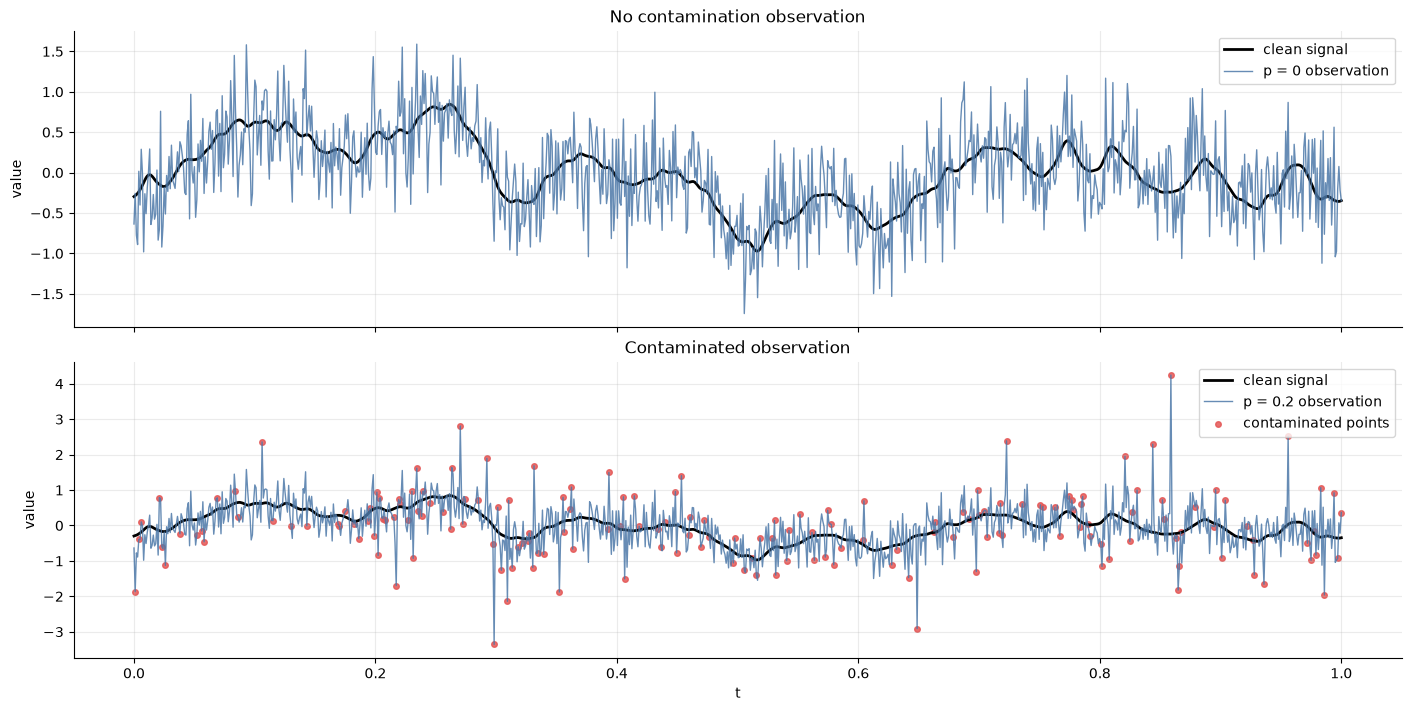

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

axes[0].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[0].plot(t, y_no_contamination, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0 observation")
axes[0].set_title("No contamination observation")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right")

mask = noise_info["contamination_mask"]
axes[1].plot(t, x_clean, color="black", linewidth=2.0, label="clean signal")
axes[1].plot(t, y_observed, color="#4C78A8", linewidth=1.0, alpha=0.85, label="p = 0.2 observation")
axes[1].scatter(
    t[mask],
    y_observed[mask],
    s=16,
    color="#E45756",
    alpha=0.85,
    label="contaminated points",
)
axes[1].set_title("Contaminated observation")
axes[1].set_xlabel("t")
axes[1].set_ylabel("value")
axes[1].legend(loc="upper right")

plt.show()

## Component error summary

The table reports both the recursive IMF-component error and the single-pass window error. The recursive columns correspond to `calculated_imf - real_imf` for the extracted IMF components. The single-pass columns apply each stage's window directly to the original clean/calculated observations, which is the quantity expected to grow as the window size decreases.

In [23]:
def rmse(values):
    values = np.asarray(values, dtype=float)
    return np.sqrt(np.mean(values ** 2))


def summarize_error(error, stage_index, prefix):
    error = np.asarray(error, dtype=float)
    scaled_error = scale_error_by_stage(error, stage_index)
    sup_error = np.max(np.abs(error))
    scaled_sup_error = np.max(np.abs(scale_sup_error_by_stage(error, stage_index)))
    return {
        f"{prefix}_error_mean": np.mean(error),
        f"{prefix}_error_mae": np.mean(np.abs(error)),
        f"{prefix}_error_rmse": rmse(error),
        f"{prefix}_scaled_error_rmse": rmse(scaled_error),
        f"{prefix}_sup_error": sup_error,
        f"{prefix}_scaled_sup_error": scaled_sup_error,
        f"{prefix}_error_max_abs": sup_error,
    }


def error_value_frame(case_name, stage_index, window_size, error_family, error):
    error = np.asarray(error, dtype=float)
    scaled_error = scale_sup_error_by_stage(error, stage_index)
    t_values = np.asarray(t, dtype=float)
    return pd.concat(
        [
            pd.DataFrame({
                "case": case_name,
                "stage": stage_index,
                "window_size": window_size,
                "error_family": error_family,
                "scale": "raw",
                "t": t_values,
                "error_value": error,
            }),
            pd.DataFrame({
                "case": case_name,
                "stage": stage_index,
                "window_size": window_size,
                "error_family": error_family,
                "scale": "a^(k/2)",
                "t": t_values,
                "error_value": scaled_error,
            }),
        ],
        ignore_index=True,
    )


def component_error_frames(case_name, real_result, calculated_result):
    rows = []
    value_frames = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        real_imf = real_result["imfs"][stage_index - 1]
        calculated_imf = calculated_result["imfs"][stage_index - 1]
        recursive_error = calculated_imf - real_imf
        rows.append({
            "case": case_name,
            "stage": stage_index,
            "window_size": window_size,
            **summarize_error(recursive_error, stage_index, "recursive"),
        })
        value_frames.append(
            error_value_frame(case_name, stage_index, window_size, "recursive", recursive_error)
        )
    return pd.DataFrame(rows), pd.concat(value_frames, ignore_index=True)


def linear_single_pass_error(real_signal, calculated_signal, window_size):
    return local_linear_filter(
        np.asarray(calculated_signal, dtype=float) - np.asarray(real_signal, dtype=float),
        window_size,
    )


def robust_single_pass_error(real_signal, calculated_signal, window_size):
    real_single_pass = local_robust_gd_filter(
        real_signal,
        window_size,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=DEFAULT_MAX_WORKERS,
    )
    calculated_single_pass = local_robust_gd_filter(
        calculated_signal,
        window_size,
        H=H,
        grid=lookup_grid,
        max_iter=60,
        tol=1e-6,
        max_workers=DEFAULT_MAX_WORKERS,
    )
    return calculated_single_pass - real_single_pass


def single_pass_error_frames(case_name, error_function):
    rows = []
    value_frames = []
    for stage_index, window_size in enumerate(window_sizes, start=1):
        single_pass_error = error_function(window_size)
        rows.append({
            "case": case_name,
            "stage": stage_index,
            "window_size": window_size,
            **summarize_error(single_pass_error, stage_index, "single_pass"),
        })
        value_frames.append(
            error_value_frame(case_name, stage_index, window_size, "single_pass", single_pass_error)
        )
    return pd.DataFrame(rows), pd.concat(value_frames, ignore_index=True)


recursive_frames = [
    component_error_frames("no contamination / linear", real_linear, calculated_linear),
    component_error_frames("p = 0.2 / robust", real_robust, calculated_robust),
]

single_pass_frames = [
    single_pass_error_frames(
        "no contamination / linear",
        lambda window_size: linear_single_pass_error(x_clean, y_no_contamination, window_size),
    ),
    single_pass_error_frames(
        "p = 0.2 / robust",
        lambda window_size: robust_single_pass_error(x_clean, y_observed, window_size),
    ),
]

recursive_error_summary = pd.concat(
    [summary for summary, _ in recursive_frames],
    ignore_index=True,
)

single_pass_error_summary = pd.concat(
    [summary for summary, _ in single_pass_frames],
    ignore_index=True,
)

error_values = pd.concat(
    [values for _, values in recursive_frames + single_pass_frames],
    ignore_index=True,
)

error_summary = recursive_error_summary.merge(
    single_pass_error_summary,
    on=["case", "stage", "window_size"],
    validate="one_to_one",
)

error_summary[
    [
        "case",
        "stage",
        "window_size",
        "recursive_error_rmse",
        "single_pass_error_rmse",
        "recursive_scaled_error_rmse",
        "single_pass_scaled_error_rmse",
        "recursive_sup_error",
        "single_pass_sup_error",
        "recursive_scaled_sup_error",
        "single_pass_scaled_sup_error",
    ]
]


,case,stage,window_size,recursive_error_rmse,single_pass_error_rmse,recursive_scaled_error_rmse,single_pass_scaled_error_rmse,recursive_sup_error,single_pass_sup_error,recursive_scaled_sup_error,single_pass_scaled_sup_error
0,no contamination / linear,1,501,0.024080,0.024080,0.020249,0.020249,0.045424,0.045424,0.038197,0.038197
1,no contamination / linear,2,355,0.010586,0.028028,0.007485,0.019819,0.021843,0.056920,0.015445,0.040248
2,no contamination / linear,3,251,0.009927,0.032454,0.005903,0.019297,0.022369,0.067865,0.013301,0.040353
3,no contamination / linear,4,177,0.010339,0.037208,0.005170,0.018604,0.032164,0.081466,0.016082,0.040733
4,no contamination / linear,5,125,0.013394,0.042871,0.005631,0.018025,0.042606,0.101197,0.017914,0.042548
5,no contamination / linear,6,89,0.018929,0.051277,0.006692,0.018129,0.054099,0.134738,0.019127,0.047637
6,no contamination / linear,7,63,0.024960,0.064341,0.007421,0.019129,0.070330,0.177959,0.020909,0.052908
7,no contamination / linear,8,45,0.026529,0.079653,0.006632,0.019913,0.088463,0.218581,0.022116,0.054645
8,no contamination / linear,9,31,0.033173,0.099071,0.006974,0.020827,0.111825,0.321398,0.023508,0.067566
9,p = 0.2 / robust,1,501,0.034567,0.034567,0.029067,0.029067,0.064430,0.064430,0.054179,0.054179


## Comparison grids

Each row is one IMF stage. The grid error columns show the recursive IMF-component error $e_k$, not the single-pass diagnostic. Within each grid, both IMF columns share one min/max y-axis range, the error column has its own min/max range, and the scaled-error column has its own min/max range.

In [24]:
def min_max_limits(*arrays, pad_fraction=0.06, min_span=1e-6):
    values = np.concatenate([np.ravel(np.asarray(array, dtype=float)) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1.0, 1.0)

    low = float(np.min(values))
    high = float(np.max(values))
    if high - low < min_span:
        center = 0.5 * (low + high)
        return (center - 0.5, center + 0.5)

    pad = pad_fraction * (high - low)
    return (low - pad, high + pad)


def comparison_column_limits(real_result, calculated_result):
    real_imfs = np.asarray(real_result["imfs"], dtype=float)
    calculated_imfs = np.asarray(calculated_result["imfs"], dtype=float)
    errors = calculated_imfs - real_imfs
    stage_indices = np.arange(1, errors.shape[0] + 1, dtype=float)[:, None]
    scaled_errors = scale_error_by_stage(errors, stage_indices)

    return {
        "imf": min_max_limits(real_imfs, calculated_imfs),
        "error": min_max_limits(errors),
        "scaled_error": min_max_limits(scaled_errors),
    }


def plot_imf_comparison_grid(real_result, calculated_result, calculated_label, title):
    n_stages = len(window_sizes)
    limits = comparison_column_limits(real_result, calculated_result)

    fig, axes = plt.subplots(
        n_stages,
        4,
        figsize=(18, 2.25 * n_stages),
        sharex=True,
        constrained_layout=True,
    )

    column_titles = ["Real IMF", calculated_label, "Recursive error", "Recursive error / a^(k/2)"]
    for col, column_title in enumerate(column_titles):
        axes[0, col].set_title(column_title, fontsize=12)

    for row, window_size in enumerate(window_sizes):
        real_imf = real_result["imfs"][row]
        calculated_imf = calculated_result["imfs"][row]
        error = calculated_imf - real_imf
        scaled_error = scale_error_by_stage(error, row + 1)

        axes[row, 0].plot(t, real_imf, color="black", linewidth=1.25)
        axes[row, 0].set_ylim(*limits["imf"])
        axes[row, 0].set_ylabel(f"IMF {row + 1}\nwindow={window_size}")

        axes[row, 1].plot(t, calculated_imf, color="#4C78A8", linewidth=1.1)
        axes[row, 1].set_ylim(*limits["imf"])

        axes[row, 2].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 2].plot(t, error, color="#E45756", linewidth=1.0)
        axes[row, 2].set_ylim(*limits["error"])

        axes[row, 3].axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        axes[row, 3].plot(t, scaled_error, color="#54A24B", linewidth=1.0)
        axes[row, 3].set_ylim(*limits["scaled_error"])

        for col in range(4):
            axes[row, col].tick_params(axis="both", labelsize=8)
            axes[row, col].margins(x=0.0)

    for ax in axes[-1, :]:
        ax.set_xlabel("t")

    fig.suptitle(title, fontsize=15)
    return fig, axes

def fit_line(x, y):
    slope, intercept = np.polyfit(np.asarray(x, dtype=float), np.asarray(y, dtype=float), deg=1)
    return float(slope), float(intercept)


def plot_error_trend(case_name, title, min_stage=1):
    case_df = error_summary.loc[
        (error_summary["case"] == case_name)
        & (error_summary["stage"] >= min_stage)
    ].copy()
    if case_df.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    x = case_df["stage"].to_numpy(dtype=float)
    metrics = [
        ("recursive_error_rmse", "Recursive IMF RMSE(error)", "#E45756", "recursive"),
        ("single_pass_error_rmse", "Single-pass RMSE(error)", "#F58518", "single_pass"),
        ("recursive_scaled_error_rmse", "Recursive IMF RMSE(error / a^(k/2))", "#54A24B", "recursive"),
        ("single_pass_scaled_error_rmse", "Single-pass RMSE(error / a^(k/2))", "#72B7B2", "single_pass"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    coefficient_rows = []
    plot_rows = []
    y_limit_values = {"recursive": [], "single_pass": []}

    for column, label, color, limit_group in metrics:
        y = case_df[column].to_numpy(dtype=float)
        slope, intercept = fit_line(x, y)
        y_limit_values[limit_group].append(y)
        plot_rows.append((column, label, color, limit_group, y))

        coefficient_rows.append({
            "case": case_name,
            "min_stage": min_stage,
            "metric": label,
            "slope": slope,
            "intercept": intercept,
        })

    y_limits = {
        limit_group: min_max_limits(*values)
        for limit_group, values in y_limit_values.items()
    }

    for ax, (_, label, color, limit_group, y) in zip(axes, plot_rows):
        ax.plot(x, y, marker="o", color=color, linewidth=1.4, label=label)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("RMSE over t")
        ax.set_xticks(case_df["stage"])
        ax.set_ylim(*y_limits[limit_group])
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(title, fontsize=14)
    coefficients = pd.DataFrame(coefficient_rows)
    display(coefficients)
    return fig, axes, coefficients


def plot_sup_error_trend(case_name, title, min_stage=1):
    case_df = error_summary.loc[
        (error_summary["case"] == case_name)
        & (error_summary["stage"] >= min_stage)
    ].copy()
    if case_df.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    x = case_df["stage"].to_numpy(dtype=float)
    metrics = [
        ("recursive_sup_error", "Recursive IMF sup(error)", "#E45756", "recursive"),
        ("single_pass_sup_error", "Single-pass sup(error)", "#F58518", "single_pass"),
        ("recursive_scaled_sup_error", "Recursive IMF sup(error / a^(k/2))", "#54A24B", "recursive"),
        ("single_pass_scaled_sup_error", "Single-pass sup(error / a^(k/2))", "#72B7B2", "single_pass"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)
    coefficient_rows = []
    plot_rows = []
    y_limit_values = {"recursive": [], "single_pass": []}

    for column, label, color, limit_group in metrics:
        y = case_df[column].to_numpy(dtype=float)
        slope, intercept = fit_line(x, y)
        y_limit_values[limit_group].append(y)
        plot_rows.append((column, label, color, limit_group, y))

        coefficient_rows.append({
            "case": case_name,
            "min_stage": min_stage,
            "metric": label,
            "slope": slope,
            "intercept": intercept,
        })

    y_limits = {
        limit_group: min_max_limits(*values)
        for limit_group, values in y_limit_values.items()
    }

    for ax, (_, label, color, limit_group, y) in zip(axes, plot_rows):
        ax.plot(x, y, marker="o", color=color, linewidth=1.4, label=label)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("sup_t |error|")
        ax.set_xticks(case_df["stage"])
        ax.set_ylim(*y_limits[limit_group])
        ax.legend(loc="best", fontsize=8)

    fig.suptitle(title, fontsize=14)
    coefficients = pd.DataFrame(coefficient_rows)
    display(coefficients)
    return fig, axes, coefficients


def plot_error_boxplots(case_name, title, min_stage=1):
    case_values = error_values.loc[
        (error_values["case"] == case_name)
        & (error_values["stage"] >= min_stage)
    ].copy()
    if case_values.empty:
        raise ValueError(f"No rows found for case: {case_name} with min_stage={min_stage}")

    panels = [
        ("recursive", "raw", "Recursive IMF error", "#E45756"),
        ("single_pass", "raw", "Single-pass error", "#F58518"),
        ("recursive", "a^(k/2)", "Recursive IMF error / a^(k/2)", "#54A24B"),
        ("single_pass", "a^(k/2)", "Single-pass error / a^(k/2)", "#72B7B2"),
    ]
    stages = np.sort(case_values["stage"].unique())
    y_limits = {
        scale: min_max_limits(case_values.loc[case_values["scale"] == scale, "error_value"])
        for scale in case_values["scale"].unique()
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 7.5), sharex=True, constrained_layout=True)
    axes = np.ravel(axes)

    for ax, (error_family, scale, label, color) in zip(axes, panels):
        panel = case_values.loc[
            (case_values["error_family"] == error_family)
            & (case_values["scale"] == scale)
        ]
        data = [
            panel.loc[panel["stage"] == stage, "error_value"].to_numpy(dtype=float)
            for stage in stages
        ]
        boxplot = ax.boxplot(
            data,
            positions=stages,
            widths=0.55,
            patch_artist=True,
            tick_labels=[str(int(stage)) for stage in stages],
            flierprops={"marker": ".", "markersize": 2.0, "alpha": 0.25},
            medianprops={"color": "black", "linewidth": 1.1},
        )
        for patch in boxplot["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.35)
            patch.set_edgecolor(color)
        for whisker in boxplot["whiskers"]:
            whisker.set_color(color)
        for cap in boxplot["caps"]:
            cap.set_color(color)

        ax.axhline(0.0, color="#666666", linewidth=0.8, alpha=0.65)
        ax.set_title(label)
        ax.set_xlabel("IMF count k")
        ax.set_ylabel("signed error")
        ax.set_ylim(*y_limits[scale])

    fig.suptitle(title, fontsize=14)
    return fig, axes


### No contamination: linear IMF

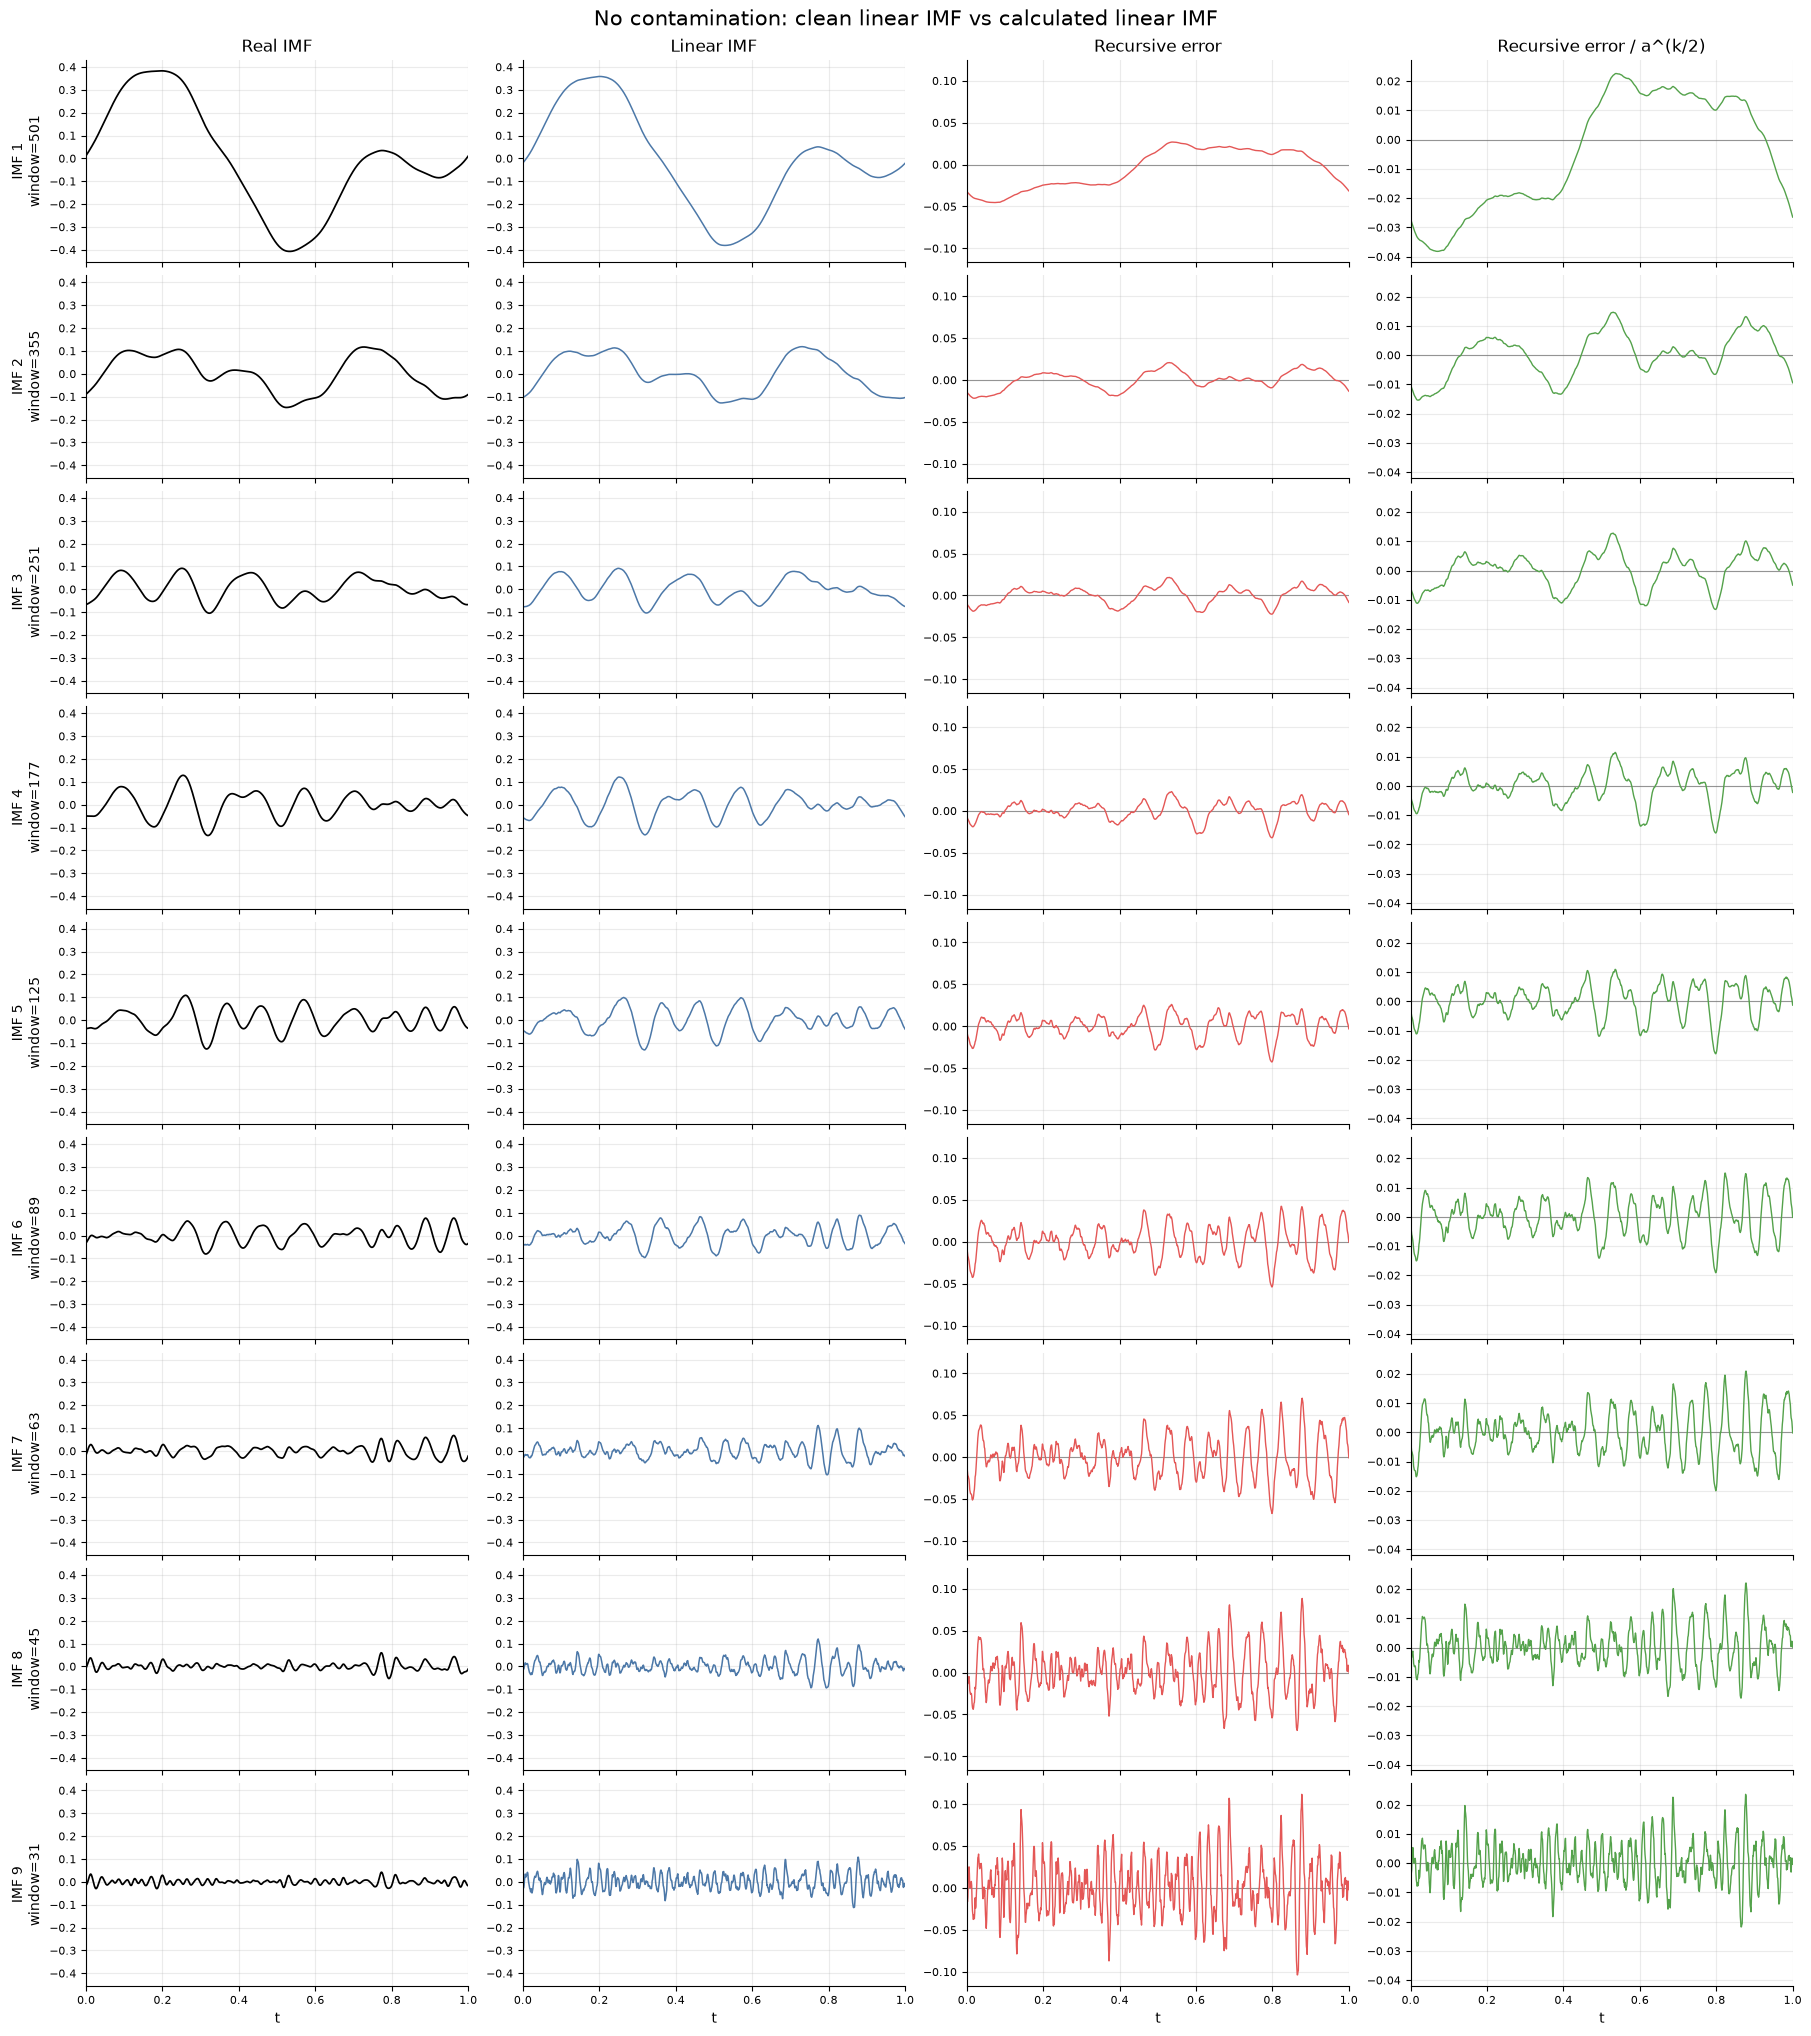

In [25]:
plot_imf_comparison_grid(
    real_linear,
    calculated_linear,
    calculated_label="Linear IMF",
    title="No contamination: clean linear IMF vs calculated linear IMF",
)
plt.show()

### No contamination: error trends

,case,min_stage,metric,slope,intercept
0,no contamination / linear,1,Recursive IMF RMSE(error),0.002048,0.008864
1,no contamination / linear,1,Single-pass RMSE(error),0.008878,0.006608
2,no contamination / linear,1,Recursive IMF RMSE(error / a^(k/2)),-0.000852,0.012276
3,no contamination / linear,1,Single-pass RMSE(error / a^(k/2)),0.000030,0.019184


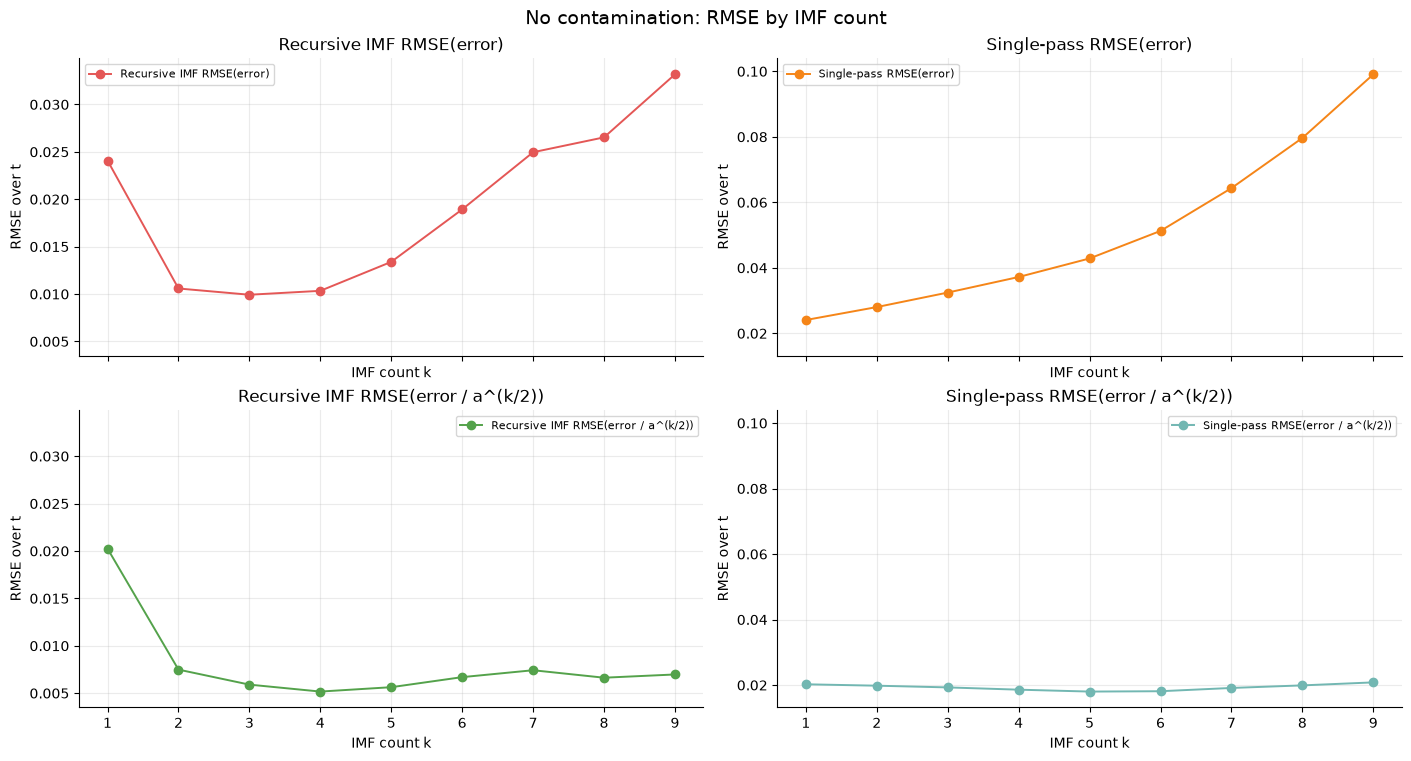

In [26]:
plot_error_trend(
    case_name="no contamination / linear",
    title="No contamination: RMSE by IMF count",
)
plt.show()

### No contamination: sup-error trends and boxplots

The sup-error panels plot `max_t |error_k(t)|`. Boxplots show signed errors over `t`, with scaled panels divided by `a ** (k / 2)`.


,case,min_stage,metric,slope,intercept
0,no contamination / linear,1,Recursive IMF sup(error),0.009722,0.005737
1,no contamination / linear,1,Single-pass sup(error),0.031039,-0.021245
2,no contamination / linear,1,Recursive IMF sup(error / a^(k/2)),-0.000341,0.022440
3,no contamination / linear,1,Single-pass sup(error / a^(k/2)),0.003211,0.031147


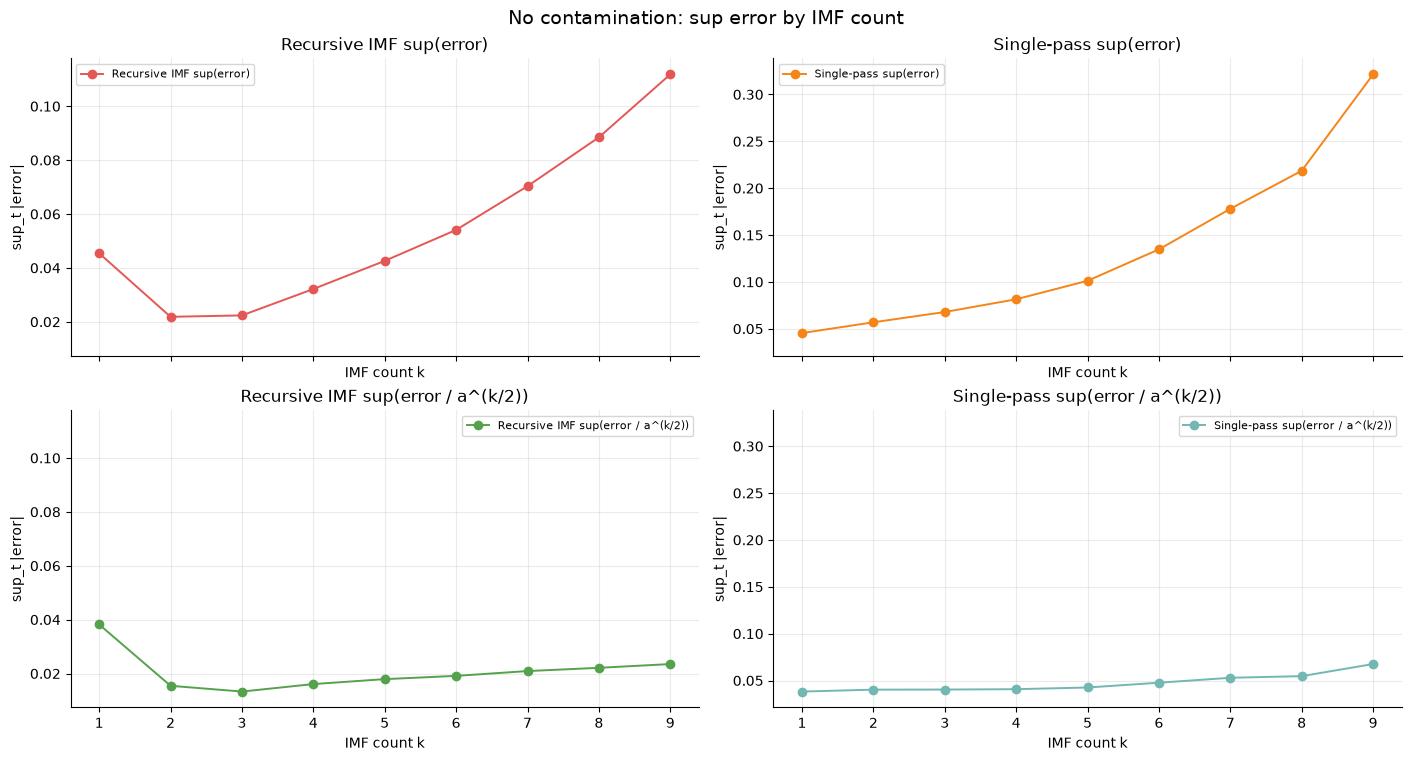

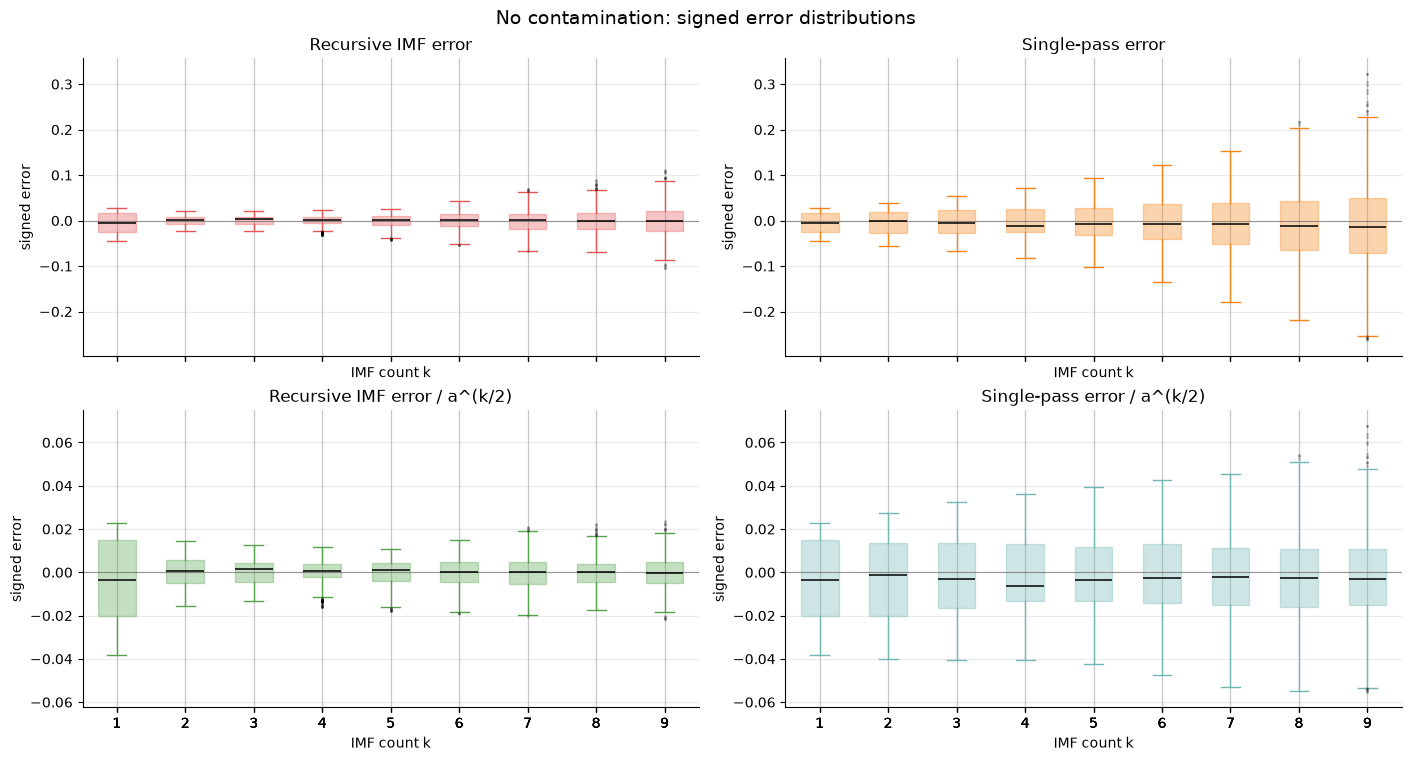

In [27]:
plot_sup_error_trend(
    case_name="no contamination / linear",
    title="No contamination: sup error by IMF count",
)
plt.show()

plot_error_boxplots(
    case_name="no contamination / linear",
    title="No contamination: signed error distributions",
)
plt.show()


### With contamination: robust IMF

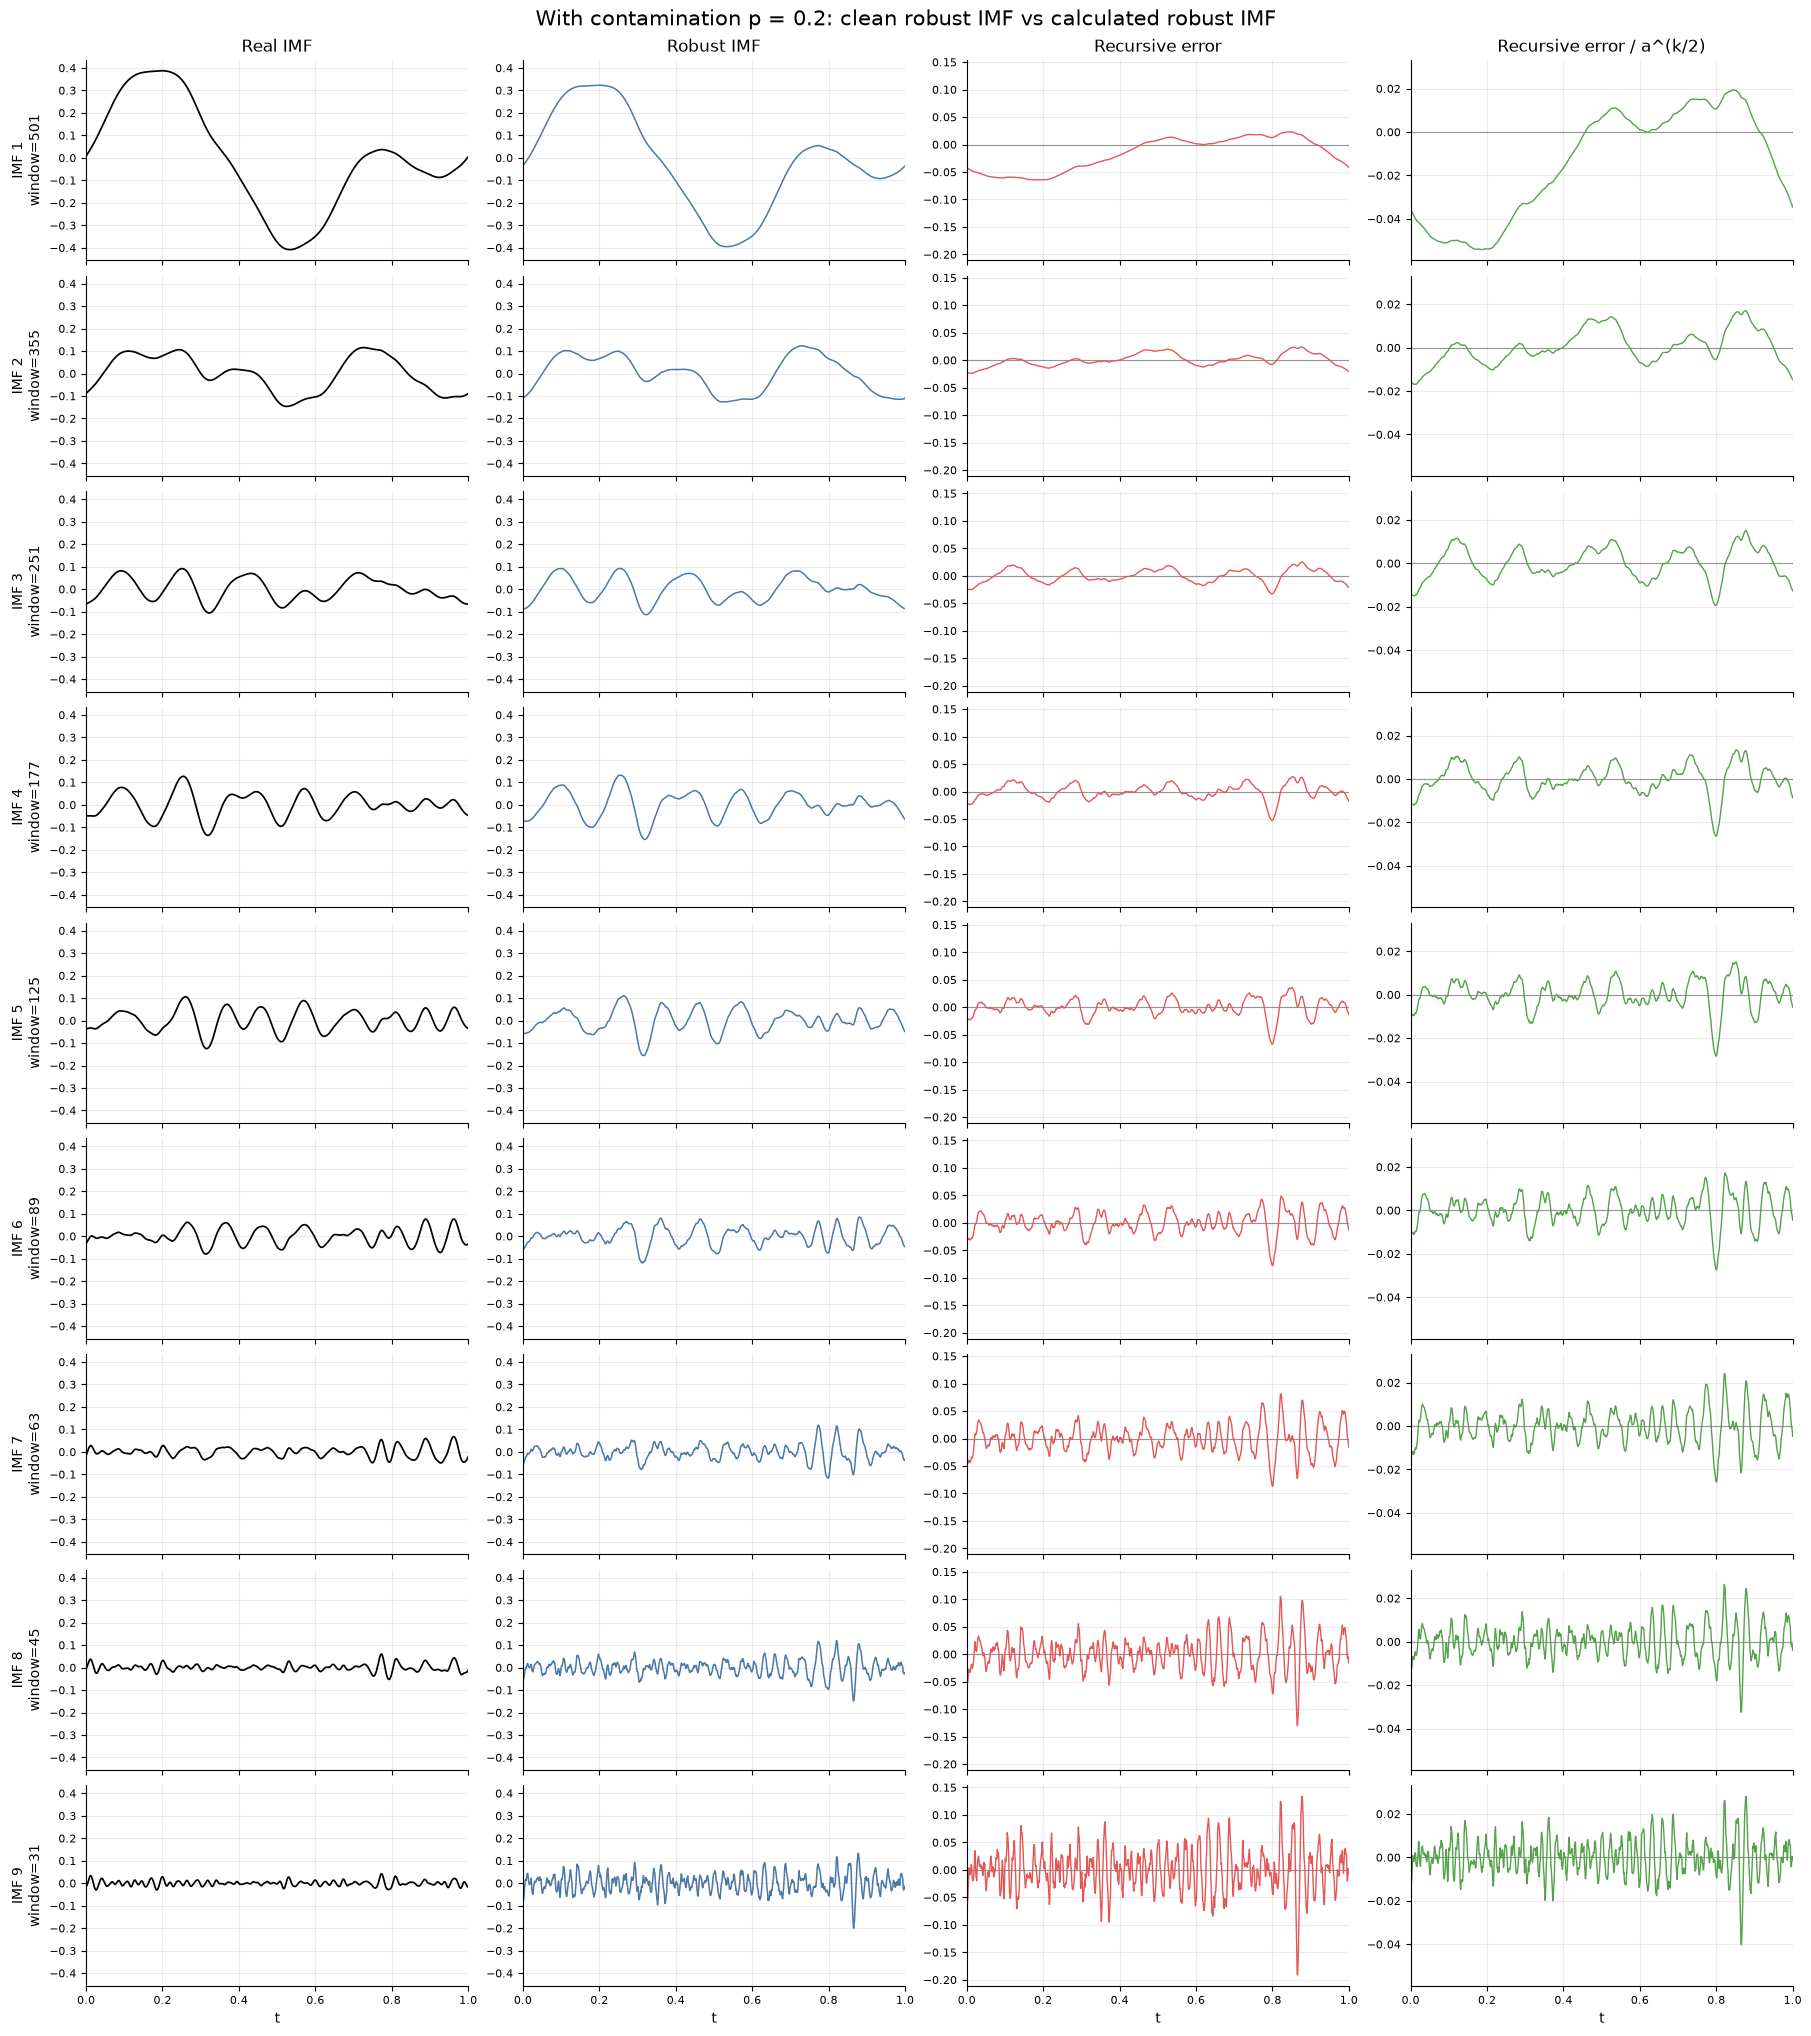

In [28]:
plot_imf_comparison_grid(
    real_robust,
    calculated_robust,
    calculated_label="Robust IMF",
    title="With contamination p = 0.2: clean robust IMF vs calculated robust IMF",
)
plt.show()

### With contamination: error trends

,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,1,Recursive IMF RMSE(error),0.001771,0.013530
1,p = 0.2 / robust,1,Single-pass RMSE(error),0.009346,0.016147
2,p = 0.2 / robust,1,Recursive IMF RMSE(error / a^(k/2)),-0.001401,0.016774
3,p = 0.2 / robust,1,Single-pass RMSE(error / a^(k/2)),-0.000658,0.027893


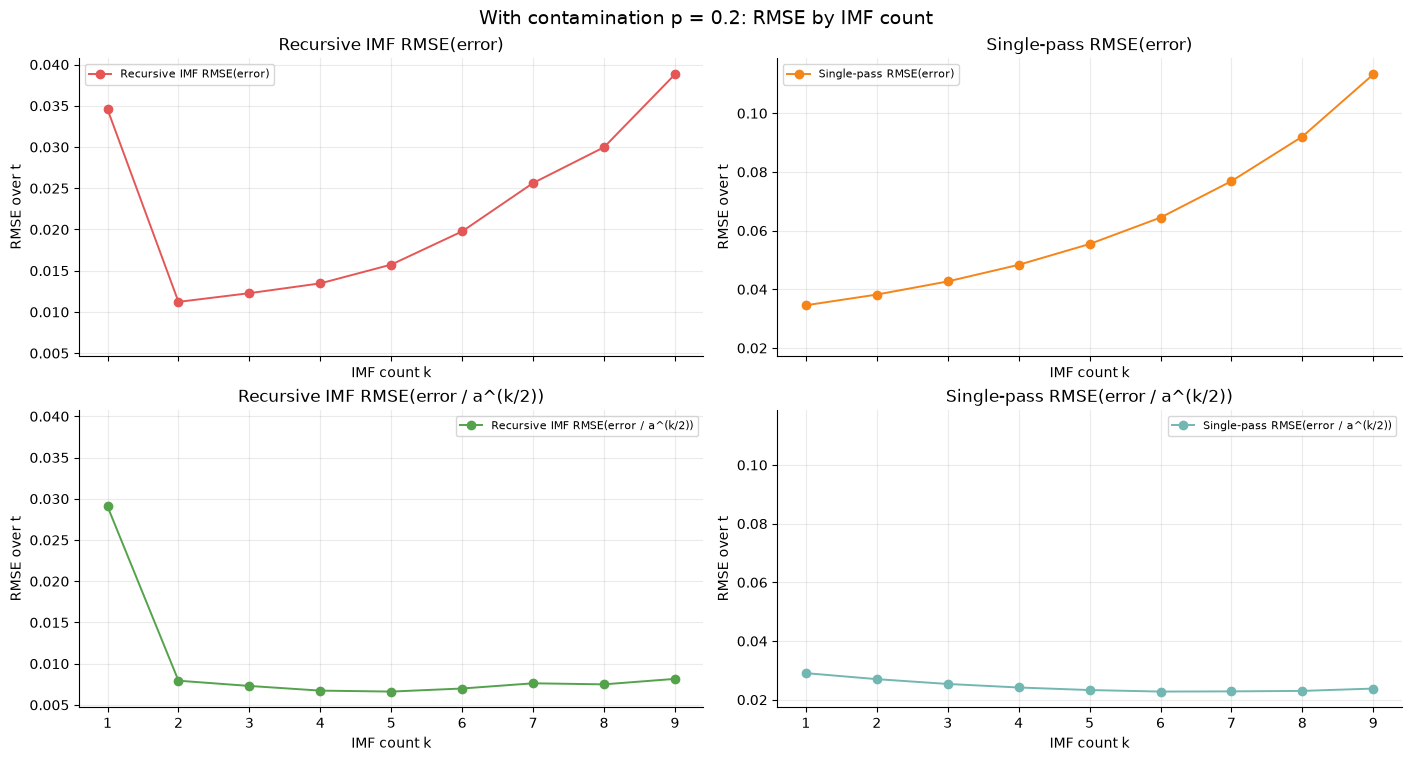

In [29]:
plot_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: RMSE by IMF count",
)
plt.show()

### With contamination: sup-error trends and boxplots

The sup-error panels plot `max_t |error_k(t)|`. Boxplots show signed errors over `t`, with scaled panels divided by `a ** (k / 2)`.


,case,min_stage,metric,slope,intercept
0,p = 0.2 / robust,1,Recursive IMF sup(error),0.015981,0.000872
1,p = 0.2 / robust,1,Single-pass sup(error),0.038613,-0.024180
2,p = 0.2 / robust,1,Recursive IMF sup(error / a^(k/2)),0.000076,0.029760
3,p = 0.2 / robust,1,Single-pass sup(error / a^(k/2)),0.003755,0.041007


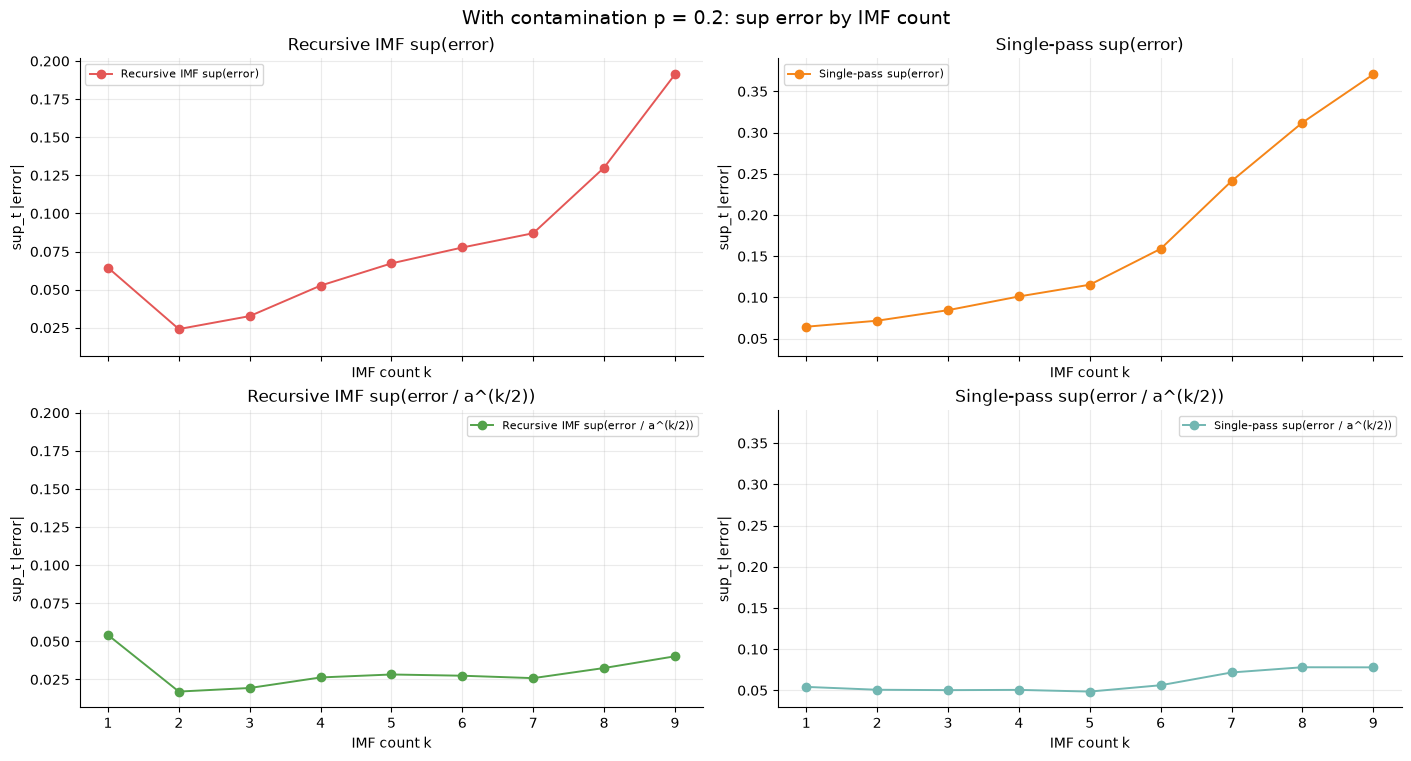

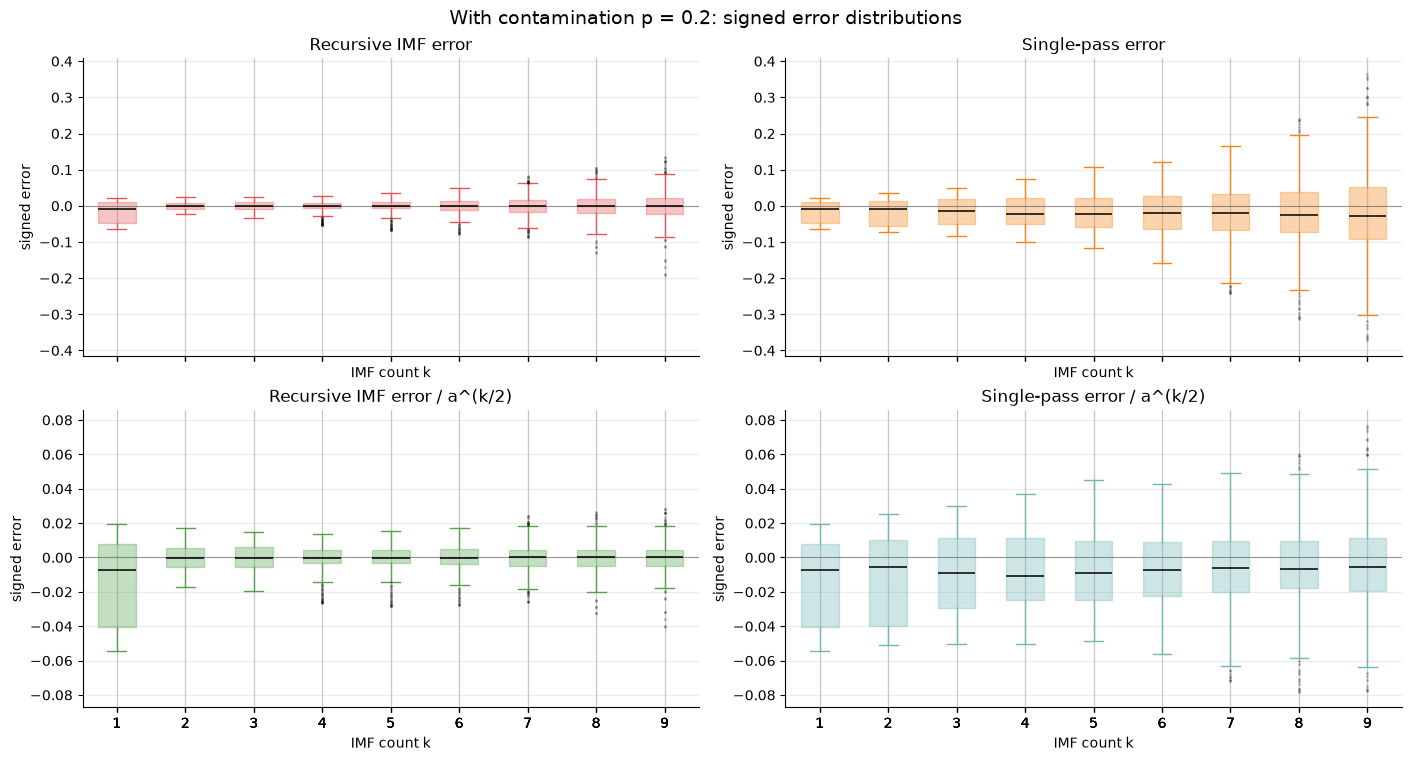

In [30]:
plot_sup_error_trend(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: sup error by IMF count",
)
plt.show()

plot_error_boxplots(
    case_name="p = 0.2 / robust",
    title="With contamination p = 0.2: signed error distributions",
)
plt.show()
